# No-Show Appointment Classifier
Training pipeline for predicting medical appointment no-shows.
Outputs a trained model saved to `model.pkl` for use by the streaming inference runner.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_PATH = 'data/KaggleV2-May-2016.csv'

## 1. Load & Feature Engineering
Convert raw strings to numbers the model can use.

**Features added:**
- `days_until_appt` — derived from date strings
- `neighbourhood_*` — one-hot encoded (80 neighbourhoods, drop first to avoid multicollinearity)
- `patient_noshow_rate` — historical no-show rate per patient using only *past* appointments (computed in date order to prevent leakage)
- `patient_appt_count` — how many times this patient has been seen before

In [2]:
df = pd.read_csv(DATA_PATH)

# --- date features ---
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['days_until_appt'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days.clip(lower=0)

# --- gender string -> binary ---
df['Gender'] = (df['Gender'] == 'F').astype(int)

# --- label ---
df['no_show'] = (df['No-show'] == 'Yes').astype(int)

# --- neighbourhood one-hot (drop_first avoids multicollinearity) ---
neighbourhood_dummies = pd.get_dummies(df['Neighbourhood'], prefix='nb', drop_first=True)
df = pd.concat([df, neighbourhood_dummies], axis=1)
neighbourhood_cols = neighbourhood_dummies.columns.tolist()
print(f"Neighbourhood columns added: {len(neighbourhood_cols)}")

# --- patient historical no-show rate (leakage-safe) ---
# Sort by appointment date so cumulative stats only use past appointments
df = df.sort_values('AppointmentDay').reset_index(drop=True)

# cumsum() - current row = sum of all PREVIOUS rows for this patient
df['prev_noshow_count'] = (
    df.groupby('PatientId')['no_show'].cumsum() - df['no_show']
)
# cumcount() = number of rows BEFORE this one for this patient
df['patient_appt_count'] = df.groupby('PatientId').cumcount()

# rate = previous no-shows / previous appointments
# first appointment has no history -> fill with global mean (no leakage: global mean is a prior)
global_noshow_rate = df['no_show'].mean()
df['patient_noshow_rate'] = (
    df['prev_noshow_count'] / df['patient_appt_count'].replace(0, np.nan)
).fillna(global_noshow_rate)

FEATURES = (
    ['Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes',
     'Alcoholism', 'Handcap', 'SMS_received', 'days_until_appt',
     'patient_noshow_rate', 'patient_appt_count']
    + neighbourhood_cols
)
TARGET = 'no_show'

print(f"\nTotal features: {len(FEATURES)}")
print(f"Shape: {df.shape}")
print(f"No-show rate: {df[TARGET].mean():.1%}")
print(df[['patient_appt_count', 'patient_noshow_rate', 'no_show']].head(10))

Neighbourhood columns added: 80

Total features: 91
Shape: (110527, 99)
No-show rate: 20.2%
   patient_appt_count  patient_noshow_rate  no_show
0                   0             0.201933        0
1                   0             0.201933        0
2                   0             0.201933        0
3                   0             0.201933        0
4                   0             0.201933        0
5                   0             0.201933        1
6                   0             0.201933        0
7                   0             0.201933        0
8                   0             0.201933        0
9                   0             0.201933        0


## 2. Split Data
- **10% streaming** — held out, never seen by the training pipeline, replayed as a live stream later
- **90% modeling pool** → 80% train / 10% val / 10% test

In [3]:
X = df[FEATURES]
y = df[TARGET]

# carve off streaming split first
X_model, X_stream, y_model, y_stream = train_test_split(
    X, y, test_size=0.10, random_state=RANDOM_STATE, stratify=y
)

# split modeling pool into train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model, y_model, test_size=0.20, random_state=RANDOM_STATE, stratify=y_model
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# save streaming split for later use by the runner
stream_df = X_stream.copy()
stream_df[TARGET] = y_stream.values
stream_df.to_csv('data/stream.csv', index=False)

print(f"Train:     {X_train.shape[0]:>6} rows  ({X_train.shape[0]/len(X):.1%})")
print(f"Val:       {X_val.shape[0]:>6} rows  ({X_val.shape[0]/len(X):.1%})")
print(f"Test:      {X_test.shape[0]:>6} rows  ({X_test.shape[0]/len(X):.1%})")
print(f"Streaming: {X_stream.shape[0]:>6} rows  ({X_stream.shape[0]/len(X):.1%})")
print(f"\nNo-show rate — train: {y_train.mean():.1%}  val: {y_val.mean():.1%}  test: {y_test.mean():.1%}")

Train:      79579 rows  (72.0%)
Val:         9947 rows  (9.0%)
Test:        9948 rows  (9.0%)
Streaming:  11053 rows  (10.0%)

No-show rate — train: 20.2%  val: 20.2%  test: 20.2%


## 3. Hyperparameter Search
RandomizedSearchCV runs 5-fold cross-validation internally on the train set for each candidate.
Val set is not touched here — it's used after to pick between finalists.

In [4]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15, 20, None],
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf':  [10, 20, 50, 100],
    'class_weight':      ['balanced', None],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,          # try 30 random combinations
    scoring='roc_auc',  # optimise for AUC
    cv=5,               # 5-fold CV on train set
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest CV AUC:  {search.best_score_:.4f}")
print(f"Best params:  {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best CV AUC:  0.7372
Best params:  {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 15, 'class_weight': None}


## 4. Validation Curve
Sanity check that max_depth sweet spot looks reasonable.

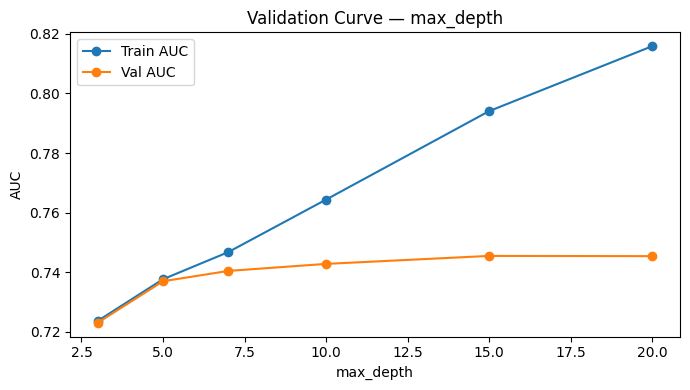

Val AUCs: {3: 0.723, 5: 0.737, 7: 0.7404, 10: 0.7428, 15: 0.7455, 20: 0.7454}


In [5]:
depths = [3, 5, 7, 10, 15, 20]
best_params = search.best_params_.copy()

train_aucs, val_aucs = [], []
for d in depths:
    m = RandomForestClassifier(**{**best_params, 'max_depth': d},
                               random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, m.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(y_val,   m.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_aucs, 'o-', label='Train AUC')
plt.plot(depths, val_aucs,   'o-', label='Val AUC')
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Validation Curve — max_depth')
plt.legend()
plt.tight_layout()
plt.savefig('validation_curve.png', dpi=120)
plt.show()
print(f"Val AUCs: {dict(zip(depths, [round(v,4) for v in val_aucs]))}")

## 5. Retrain on Train + Val, Evaluate on Test
Lock in best hyperparameters, retrain on all available labeled data, evaluate once.

Test AUC: 0.7350
✓  Within expected range for this dataset (published: 0.74-0.76)


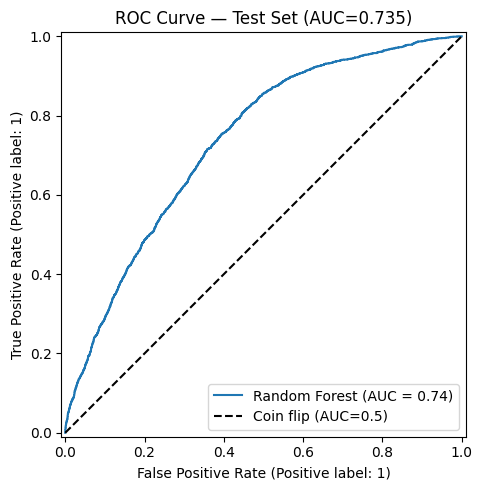

In [6]:
import pandas as pd

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_model = RandomForestClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_model.fit(X_trainval, y_trainval)

test_probs = final_model.predict_proba(X_test)[:, 1]
test_auc   = roc_auc_score(y_test, test_probs)

print(f"Test AUC: {test_auc:.4f}")
if test_auc > 0.80:
    print("⚠️  Higher than expected — check for data leakage")
elif test_auc >= 0.72:
    print("✓  Within expected range for this dataset (published: 0.74-0.76)")
else:
    print("↓  Below expected — consider feature engineering")

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, test_probs, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', label='Coin flip (AUC=0.5)')
ax.set_title(f'ROC Curve — Test Set (AUC={test_auc:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 6. Feature Importance

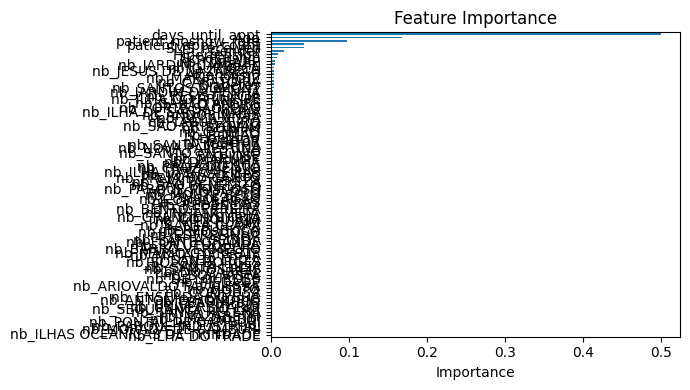

days_until_appt                   0.499348
Age                               0.168558
patient_noshow_rate               0.098292
patient_appt_count                0.042904
SMS_received                      0.042740
                                    ...   
nb_PARQUE INDUSTRIAL              0.000000
nb_MORADA DE CAMBURI              0.000000
nb_ILHAS OCEÂNICAS DE TRINDADE    0.000000
nb_PONTAL DE CAMBURI              0.000000
nb_ILHA DO FRADE                  0.000000
Length: 91, dtype: float64


In [7]:
importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax)
ax.set_title('Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print(importances.sort_values(ascending=False))

## 7. Save Model
Serialize the trained model to `model.pkl` — loaded by the streaming inference runner.

In [8]:
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'model':    final_model,
        'features': FEATURES,
        'test_auc': test_auc,
    }, f)

print(f"Saved model.pkl — AUC={test_auc:.4f}, features={FEATURES}")

Saved model.pkl — AUC=0.7350, features=['Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'days_until_appt', 'patient_noshow_rate', 'patient_appt_count', 'nb_ANDORINHAS', 'nb_ANTÔNIO HONÓRIO', 'nb_ARIOVALDO FAVALESSA', 'nb_BARRO VERMELHO', 'nb_BELA VISTA', 'nb_BENTO FERREIRA', 'nb_BOA VISTA', 'nb_BONFIM', 'nb_CARATOÍRA', 'nb_CENTRO', 'nb_COMDUSA', 'nb_CONQUISTA', 'nb_CONSOLAÇÃO', 'nb_CRUZAMENTO', 'nb_DA PENHA', 'nb_DE LOURDES', 'nb_DO CABRAL', 'nb_DO MOSCOSO', 'nb_DO QUADRO', 'nb_ENSEADA DO SUÁ', 'nb_ESTRELINHA', 'nb_FONTE GRANDE', 'nb_FORTE SÃO JOÃO', 'nb_FRADINHOS', 'nb_GOIABEIRAS', 'nb_GRANDE VITÓRIA', 'nb_GURIGICA', 'nb_HORTO', 'nb_ILHA DAS CAIEIRAS', 'nb_ILHA DE SANTA MARIA', 'nb_ILHA DO BOI', 'nb_ILHA DO FRADE', 'nb_ILHA DO PRÍNCIPE', 'nb_ILHAS OCEÂNICAS DE TRINDADE', 'nb_INHANGUETÁ', 'nb_ITARARÉ', 'nb_JABOUR', 'nb_JARDIM CAMBURI', 'nb_JARDIM DA PENHA', 'nb_JESUS DE NAZARETH', 'nb_JOANA D´ARC', 'nb_JUCUTUQUARA', 'nb_MARIA ORTIZ',